# Reduced states on a Gaussian square lattice

A random pure Gaussian network on a lattice of `FreeFermion/geometry.py`: one `GfPEPS`
node per site, carrying `ext_dim` external (physical) Majorana modes and one
`bond_dim`-Majorana bond per lattice bond, with a covariance drawn from `RandPureCov`, so
every node starts **pure**.  The lattice, its sites, its bonds and its patches come from
the geometry; the network only adds the covariances.

Two operations are easy to confuse, and they behave differently:

| operation | what it does to the modes | purity |
|---|---|---|
| contract a bond | inner product with the fermionic EPR state on the bond (`contract_sites`) | pure $\to$ pure |
| trace out a subsystem | keep the sub-block of the covariance (partial trace) | pure $\to$ mixed |

So *contract everything, then trace* is exact, while *cut the bonds first, then contract* is
the tensor-network approximation.


In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.special import digamma

from FreeFermion.GfPEPS import Bond, Graph, GfPEPS
from FreeFermion.geometry import Boundary, Geometry, honeycomb, kagome, lieb, square
from FreeFermion.linalg import RandPureCov, entropy, is_pure, occupations, purity

OPEN = (Boundary.OPEN, Boundary.OPEN)


def gaussian_network(grid: Geometry, bond_dim: int = 2, ext_dim: int = 2,
                     seed: int | None = None) -> GfPEPS:
    '''
    Random pure Gaussian network on the bonds of a geometry: one node per site, a bond of
    bond_dim Majorana modes per lattice bond, and a random pure covariance on every node.
    Args:
        grid: the geometry the network lives on; every lattice bond becomes a network bond.
        bond_dim: Majorana modes per bond.
        ext_dim: external Majorana modes per site.
        seed: optional torch seed for the random covariances.
    Returns:
        The GfPEPS with grid.sites nodes.
    '''
    if seed is not None:
        torch.manual_seed(seed)
    return GfPEPS(grid.graph(grid.bonds, [bond_dim] * len(grid.bonds)),
                  [ext_dim] * grid.sites)


def cut_patch_covariance(network: GfPEPS, sites: list[int]) -> torch.Tensor:
    '''
    The tensor-network approximation: cut every bond that leaves the patch before
    contracting, i.e. keep on each patch node only its external modes and the bond blocks
    that stay inside, and then contract the patch alone.  Selecting the legs of a node is
    enough, because its blocks are keyed by leg: dropping a bond drops its blocks and the
    entries of the matrix together.
    Args:
        network: the Gaussian network.
        sites: the original node labels of the patch.
    Returns:
        The covariance of the patch, square of size 2 * ext_dim * len(sites).
    '''
    inside = sorted(sites)
    bonds = [bond for bond in network.graph.edges
             if bond.first in inside and bond.second in inside]
    tensors, ext_dim = [], []
    for node in inside:
        legs = [None] + [bond for bond in network.graph.bonds(node) if bond in bonds]
        tensors.append(network[node].assemble(legs))
        ext_dim.append(network.ext_dim[node])
    labels = {node: index for index, node in enumerate(inside)}
    edges = tuple(Bond(labels[bond.first], labels[bond.second], bond.bond_dim)
                  for bond in bonds)
    return GfPEPS.from_covariances(Graph(len(inside), edges), ext_dim,
                                   tensors).partial_trace(list(range(len(inside))))


def draw_patches(grid: Geometry, patches: list[tuple[list[int], str]],
                 order: list[int] | None = None) -> None:
    '''
    One figure with one panel per patch: a filled node carries the modes that are kept, a
    solid bond stays inside the patch, a dashed bond leaves it.  The positions are the
    geometry's, so the same drawing works on any lattice of it.
    Args:
        grid: the geometry.
        patches: (patch, label) of every panel, the label is the title.
        order: optional walk through the sites; a node is then numbered by its position in
            it instead of by its label.
    '''
    step = {} if order is None else {node: index + 1 for index, node in enumerate(order)}
    figure, panels = plt.subplots(1, len(patches), squeeze=False,
                                  figsize=(3.0 * len(patches), 3.2))
    for axis, (patch, name) in zip(panels[0], patches):
        kept = set(patch)
        for first, second in grid.bonds:
            x0, y0 = grid.positions[first]
            x1, y1 = grid.positions[second]
            inside = first in kept and second in kept
            axis.plot([float(x0), float(x1)], [float(y0), float(y1)], zorder=1,
                      color='tab:blue' if inside else '0.75',
                      linestyle='-' if inside else '--',
                      linewidth=2.4 if inside else 1.1)
        for node in range(grid.sites):
            x, y = grid.positions[node]
            axis.scatter(float(x), float(y), s=340, zorder=2,
                         color='tab:blue' if node in kept else 'white',
                         edgecolor='tab:blue', linewidth=1.2)
            axis.text(float(x), float(y), str(step.get(node, node)), zorder=3,
                      ha='center', va='center', fontsize=7,
                      color='white' if node in kept else 'tab:blue')
        axis.set_title(name, fontsize=9)
        axis.set_aspect('equal')
        axis.axis('off')
    figure.tight_layout()
    plt.show()

## 1. What the modules provide

`GfPEPS` holds the network and its contractions:

* `state.contract_all()` — contract every bond into one node and return
  `(state, labels)`, where `labels[(node, mode)]` is the mode index in the result;
* `state.partial_trace(sites)` — the exact reduced state of a set of nodes (contract
  everything, then trace out the rest);
* `GfPEPS.from_covariances` / `from_global_covariance` / `from_hamiltonian` /
  `product_state` — public constructors instead of the private `_from_data`;
* `state[node]` — the covariance of a node as blocks keyed by leg (`state[node][a, b]`),
  so a virtual bond and the matrix entries that belong to it cannot drift apart;
* `purity`, `entropy`, `occupations`, `is_pure` (`FreeFermion/linalg.py`) — diagnostics of
  a covariance.

`FreeFermion/geometry.py` holds the lattice, and only two helpers are local to this
notebook: `gaussian_network`, which puts the random covariances on the geometry's bonds,
and `cut_patch_covariance`, the *cut the bonds first* approximation that the module
deliberately does not provide (it is not the exact reduced state).

In [2]:
size = 3
grid = square(size, size, OPEN)
sites = list(range(grid.sites))
lattice = gaussian_network(grid, ext_dim=2, bond_dim=2, seed=0)
print(f'{grid.lattice.name} {size}x{size}: {grid.sites} nodes, {len(grid.bonds)} bonds, '
      f'{sum(lattice.ext_dim)} external Majorana modes')
print(f'each node is pure          : is_pure = {is_pure(lattice.tensors[0])}, '
      f'purity = {purity(lattice.tensors[0]):.15f}')

contracted, labels = lattice.contract_all()
print(f'all bonds contracted       : {tuple(contracted.tensors[0].shape)}, '
      f'is_pure = {is_pure(contracted.tensors[0])}  <- still pure')
print('  labels[(0, 1)] =', labels[(0, 1)], ' labels[(8, 1)] =', labels[(8, 1)])

# the order of the internal bond contractions does not matter
backwards, labels_backwards = lattice.contract_all(from_end=True)
print(f'contracting back to front  : is_pure = {is_pure(backwards.tensors[0])} '
      f'(its labels record the new mode order)')
print(f'whole lattice, both orders : |diff| = '
      f'{float((lattice.partial_trace(sites) - lattice.partial_trace(sites, from_end=True)).abs().max()):.1e}')

square 3x3: 9 nodes, 12 bonds, 18 external Majorana modes
each node is pure          : is_pure = True, purity = 0.999999999999999
all bonds contracted       : (18, 18), is_pure = True  <- still pure
  labels[(0, 1)] = 1  labels[(8, 1)] = 17
contracting back to front  : is_pure = True (its labels record the new mode order)
whole lattice, both orders : |diff| = 4.2e-16


## 2. Tracing out the environment makes the patch mixed

`partial_trace` contracts **all** bonds first (pure), then keeps the sub-block of the patch,
i.e. traces out the rest.  The naive route cuts the bonds that leave the patch before
contracting, and differs.

Every patch below comes with its own picture of the $3\times3$ lattice: a filled node
carries the modes that are kept, a solid bond stays inside the patch, and a dashed bond
leaves the patch, so the naive route drops the blocks of its inner legs.

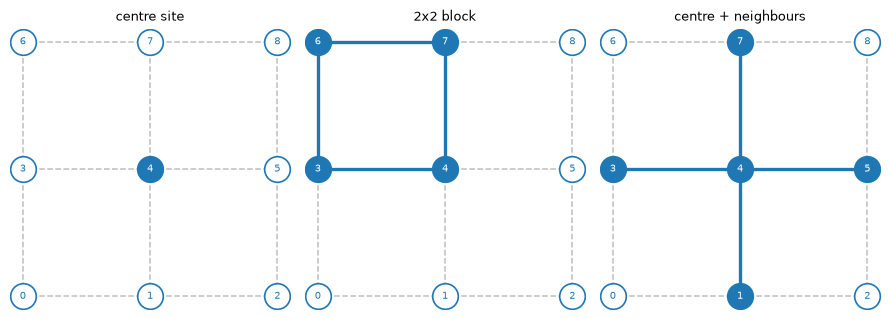

centre site (1 sites, 2 modes)
  exact  : purity = 0.5001, entropy = 0.6931, occupations = [0.49334]
  naive  : purity = 0.5087, |diff vs exact| = 0.1454
2x2 block (4 sites, 8 modes)
  exact  : purity = 0.3443, entropy = 1.2509, occupations = [0.45728, 0.1752, 0.01956, 0.0001]
  naive  : purity = 0.2911, |diff vs exact| = 0.2493
centre + neighbours (5 sites, 10 modes)
  exact  : purity = 0.2684, entropy = 1.6597, occupations = [0.37075, 0.23549, 0.06697, 0.05352, 0.0]
  naive  : purity = 0.0701, |diff vs exact| = 0.5933


In [3]:
shapes = [([4], 'centre site'), ([3, 4, 6, 7], '2x2 block'),
          ([1, 3, 4, 5, 7], 'centre + neighbours')]
draw_patches(grid, shapes)

for patch, name in shapes:
    exact = lattice.partial_trace(patch)
    naive = cut_patch_covariance(lattice, patch)
    print(f'{name} ({len(patch)} sites, {exact.shape[0]} modes)')
    print(f'  exact  : purity = {purity(exact):.4f}, entropy = {entropy(exact):.4f}, '
          f'occupations = {[round(float(x), 5) for x in occupations(exact)]}')
    print(f'  naive  : purity = {purity(naive):.4f}, |diff vs exact| = '
          f'{float((exact - naive).abs().max()):.4f}')

## 3. Growing the patch back to the whole lattice

The mixedness and the entropy come from the modes that are traced out, so they shrink as
the patch grows and vanish when the patch is the whole lattice (nothing is traced out).

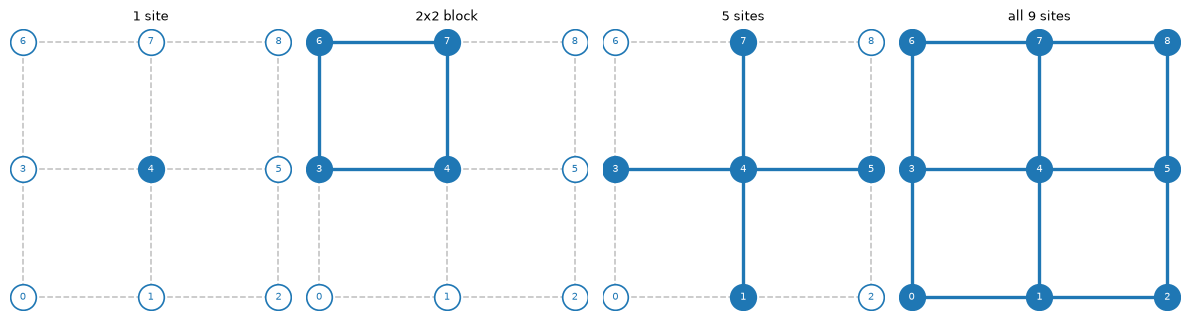

       patch  modes    purity   entropy  cut bonds   occupations
      1 site      2    0.5001    0.6931          4   [0.4933]
   2x2 block      8    0.3443    1.2509          4   [0.4573, 0.1752, 0.0196, 0.0001]
     5 sites     10    0.2684    1.6597          8   [0.3707, 0.2355, 0.067, 0.0535, 0.0]
 all 9 sites     18    1.0000    0.0000          0   [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.0, -0.0, -0.0]


In [4]:
shapes = [([4], '1 site'), ([3, 4, 6, 7], '2x2 block'),
          ([1, 3, 4, 5, 7], '5 sites'), (sites, 'all 9 sites')]
draw_patches(grid, shapes)

print(f'{"patch":>12} {"modes":>6} {"purity":>9} {"entropy":>9} {"cut bonds":>10}   occupations')
for patch, name in shapes:
    exact = lattice.partial_trace(patch)
    print(f'{name:>12} {exact.shape[0]:>6} {purity(exact):>9.4f} {entropy(exact):>9.4f} '
          f'{grid.cut_bonds(patch):>10}   {[round(float(x), 4) for x in occupations(exact)]}')

## 4. A bigger lattice: growing the patch along a snake

On a $6\times6$ lattice the patch can be grown site by site, and the growth order matters:
the snake of `Geometry.snake_order` stays compact while a random order makes a scattered
patch of the same size.  `sweep` contracts the network once and then reads the entropy and
the cut of every prefix of that order out of the same covariance, which is what makes the
whole experiment cost one contraction per seed.

8 seeds x 2 orders x 36 patch sizes in 2.0 s


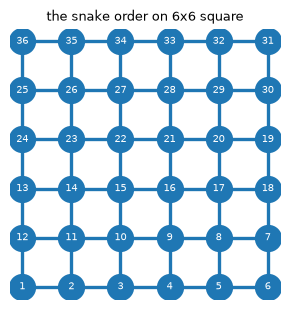

half filling (18 sites): the snake cuts 6 bonds, a random patch cuts 33.5


In [5]:
def sweep(network: GfPEPS, grid: Geometry, order: list[int]) -> tuple[np.ndarray, np.ndarray]:
    '''
    Entropy and cut size of the first n sites of the given order, for every n, out of one
    contraction of the whole network.
    Args:
        network: the Gaussian network.
        grid: the geometry, for the bonds the cut counts.
        order: the site labels in the order the patch grows.
    Returns:
        (entropies, crossings), index n-1 for a patch of the first n sites.
    '''
    state, labels = network.contract_all()
    covariance = state.tensors[0]
    entropies, crossings = [], []
    for count in range(1, grid.sites + 1):
        kept = set(order[:count])
        modes = [labels[(node, mode)] for node in sorted(kept)
                 for mode in range(network.ext_dim[node])]
        entropies.append(entropy(covariance[modes][:, modes]))
        crossings.append(grid.cut_bonds(kept))
    return np.array(entropies), np.array(crossings)


grid6 = square(6, 6, OPEN)
seeds, half = 8, grid6.sites // 2
lattice6 = gaussian_network(grid6, seed=0)
snake = grid6.snake_order()
scattered = [list(np.random.default_rng(seed).permutation(grid6.sites))
             for seed in range(seeds)]

start = time.perf_counter()
on_snake = [sweep(gaussian_network(grid6, seed=seed), grid6, snake) for seed in range(seeds)]
on_scattered = [sweep(gaussian_network(grid6, seed=seed), grid6, order)
                for seed, order in enumerate(scattered)]
print(f'{seeds} seeds x 2 orders x {grid6.sites} patch sizes in '
      f'{time.perf_counter() - start:.1f} s')

title = f'the snake order on 6x6 {grid6.lattice.name}'
draw_patches(grid6, [(list(range(grid6.sites)), title)], order=snake)
print(f'half filling ({half} sites): the snake cuts {on_snake[0][1][half - 1]} bonds, '
      f'a random patch cuts {np.mean([crossings[half - 1] for _, crossings in on_scattered]):.1f}')

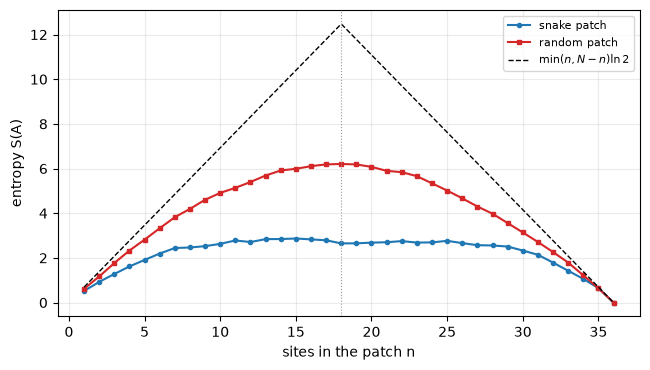

  n   snake   random   bound
  1  0.5176   0.6158  0.6931
  6  2.1942   3.3293  4.1589
 12  2.7097   5.3983  8.3178
 18  2.6497   6.2066 12.4766
 24  2.6945   5.3398  8.3178
 30  2.3300   3.1417  4.1589
 35  0.6471   0.6429  0.6931
 36  0.0000   0.0000  0.0000


In [6]:
checkerboard = [node for node in range(grid6.sites)
                if (grid6.cell[node, 0] + grid6.cell[node, 1]) % 2 == 0]
checkerboard_entropy = np.array(
    [sweep(gaussian_network(grid6, seed=seed), grid6, checkerboard)[0][half - 1]
     for seed in range(seeds)])

counts = np.arange(1, grid6.sites + 1)
snake_entropy = np.mean([values for values, _ in on_snake], axis=0)
scattered_entropy = np.mean([values for values, _ in on_scattered], axis=0)

figure, axis = plt.subplots(figsize=(6.6, 3.8))
axis.plot(counts, snake_entropy, 'o-', ms=3, color='tab:blue', label='snake patch')
axis.plot(counts, scattered_entropy, 's-', ms=3, color='tab:red', label='random patch')
axis.plot(counts, np.minimum(counts, grid6.sites - counts) * np.log(2), 'k--', lw=1.0,
          label=r'$\min(n, N-n)\ln 2$')
axis.axvline(half, color='0.6', lw=0.8, ls=':')
axis.set_xlabel('sites in the patch n')
axis.set_ylabel('entropy S(A)')
axis.legend(fontsize=8)
axis.grid(alpha=0.25)
figure.tight_layout()
plt.show()

print(f'{"n":>3} {"snake":>7} {"random":>8} {"bound":>7}')
for count in (1, 6, 12, 18, 24, 30, 35, 36):
    index = count - 1
    print(f'{count:>3} {snake_entropy[index]:>7.4f} {scattered_entropy[index]:>8.4f} '
          f'{np.minimum(count, grid6.sites - count) * np.log(2):>7.4f}')

The dashed curve is the **Page curve** $\min(n, N-n)\ln 2$, the average entropy of a
subsystem of a Haar random pure state; it is the only curve here that bounds the entropy of
every patch.  The grey curve is the average over random pure *Gaussian* states at a fixed
bipartition (Bianchi, Hackl and Kieburg, Phys. Rev. B 103, L241118 (2021), eq. (6)), drawn
against the same average measured on `RandPureCov` states.  Being an average and not a
bound, a patch of one particular state may sit above it: the star is one patch of one
state, the checkerboard at half filling, averaged over the seeds, and its spread reaches
above the average.  Both network curves stay below the two averages, and both turn over at
half filling, where the entropy of a patch is the entropy of its complement.

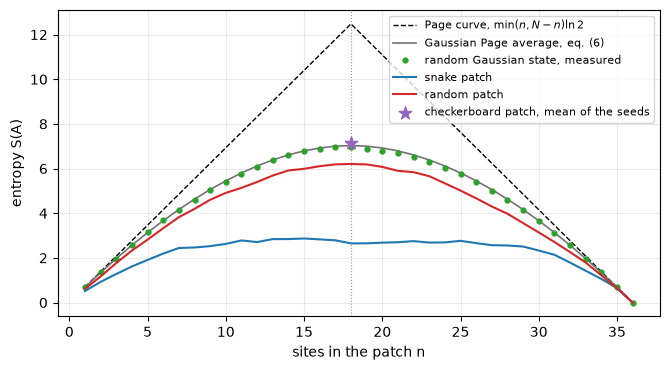

at half filling: snake 2.6497, random 6.2066, checkerboard 7.1466 (spread 0.1598)
                 Gaussian Page average 7.0318, Page bound 12.4766


In [7]:
def gaussian_page(num_modes: int, subsystem: int) -> float:
    '''
    Average entanglement entropy of a subsystem of a random pure Gaussian state,
    Bianchi-Hackl-Kieburg, Phys. Rev. B 103, L241118 (2021), eq. (6), in nats.
    Args:
        num_modes: the total number of modes N.
        subsystem: the modes of the subsystem N_A.
    Returns:
        The average entropy over the Gaussian states of N modes.
    '''
    return ((num_modes - 0.5) * digamma(2 * num_modes)
            + (0.5 + subsystem - num_modes) * digamma(2 * num_modes - 2 * subsystem)
            + (0.25 - subsystem) * digamma(num_modes)
            - 0.25 * digamma(num_modes - subsystem) - subsystem)


modes, repeats = grid6.sites, 8        # one complex mode per site
pure_gaussian = []
for seed in range(repeats):
    torch.manual_seed(seed)
    gamma = RandPureCov(2 * modes)
    pure_gaussian.append([entropy(gamma[:2 * count, :2 * count]) for count in counts])
pure_gaussian = np.mean(pure_gaussian, axis=0)

page = np.minimum(counts, grid6.sites - counts) * np.log(2)
gaussian_curve = np.array([gaussian_page(modes, min(count, grid6.sites - count))
                           for count in counts])

figure, axis = plt.subplots(figsize=(6.8, 3.8))
axis.plot(counts, page, 'k--', lw=1.0, label=r'Page curve, $\min(n, N-n)\ln 2$')
axis.plot(counts, gaussian_curve, color='0.45', lw=1.2, label='Gaussian Page average, eq. (6)')
axis.plot(counts, pure_gaussian, 'o', ms=3.5, color='tab:green',
          label='random Gaussian state, measured')
axis.plot(counts, snake_entropy, color='tab:blue', label='snake patch')
axis.plot(counts, scattered_entropy, color='tab:red', label='random patch')
axis.scatter([half], [checkerboard_entropy.mean()], marker='*', s=90, color='tab:purple',
             zorder=4, label='checkerboard patch, mean of the seeds')
axis.axvline(half, color='0.6', lw=0.8, ls=':')
axis.set_xlabel('sites in the patch n')
axis.set_ylabel('entropy S(A)')
axis.legend(fontsize=8)
axis.grid(alpha=0.25)
figure.tight_layout()
plt.show()

index = half - 1
print(f'at half filling: snake {snake_entropy[index]:.4f}, random {scattered_entropy[index]:.4f}, '
      f'checkerboard {checkerboard_entropy.mean():.4f} (spread {checkerboard_entropy.std():.4f})')
print(f'                 Gaussian Page average {gaussian_curve[index]:.4f}, '
      f'Page bound {page[index]:.4f}')

Is the cut alone enough to fix the entropy?  Growing the bond dimension at half filling makes
the cut carry more modes, and the entropy grows with it, but the entropy per cut mode falls:
the cut gives the area-law tendency, not a coefficient.

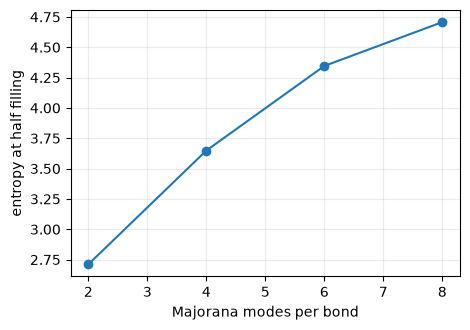

half filling against the bond dimension, snake patch
  bond_dim 2: S(half) = 2.711, the cut carries 6 bonds = 6 complex modes, S per cut mode = 0.452
  bond_dim 4: S(half) = 3.648, the cut carries 6 bonds = 12 complex modes, S per cut mode = 0.304
  bond_dim 6: S(half) = 4.346, the cut carries 6 bonds = 18 complex modes, S per cut mode = 0.241
  bond_dim 8: S(half) = 4.707, the cut carries 6 bonds = 24 complex modes, S per cut mode = 0.196


In [8]:
bond_dims, repeats = (2, 4, 6, 8), 4
half_entropy, lines = [], ['half filling against the bond dimension, snake patch']
for bond_dim in bond_dims:
    values = [sweep(gaussian_network(grid6, bond_dim=bond_dim, seed=seed), grid6, snake)[0][half - 1]
              for seed in range(repeats)]
    half_entropy.append(np.mean(values))
    cut = grid6.cut_bonds(snake[:half])
    lines.append(f'  bond_dim {bond_dim}: S(half) = {np.mean(values):.3f}, the cut carries {cut} '
                 f'bonds = {cut * bond_dim // 2} complex modes, S per cut mode = '
                 f'{np.mean(values) / (cut * bond_dim / 2):.3f}')

figure, axis = plt.subplots(figsize=(4.8, 3.4))
axis.plot(bond_dims, half_entropy, 'o-', color='tab:blue')
axis.set_xlabel('Majorana modes per bond')
axis.set_ylabel('entropy at half filling')
axis.grid(alpha=0.25)
figure.tight_layout()
plt.show()

for line in lines:
    print(line)

## 5. The largest patch of a given size

Section 4 fixes the growth order and varies the size; here the size is fixed at half
filling, 18 of the 36 sites, and the question is how much the *shape* of a patch matters.
All the patches below are cut out of the same state, and the two Page values of section 4
are drawn with them for comparison.

               patch  cut bonds   entropy
          three rows          6    2.6996
  random, mean of 20               6.3698
        checkerboard         60    7.4485
       greedy search         42    7.9180
Gaussian Page average               7.0318
          Page bound              12.4766


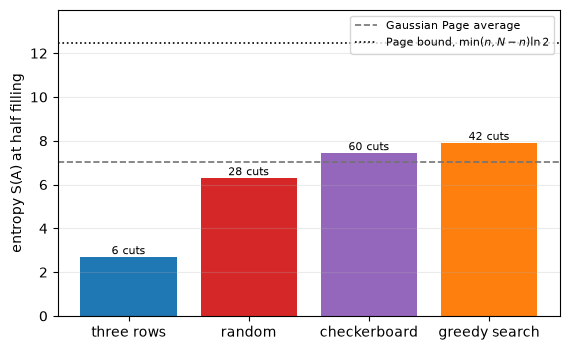

the greedy patch cuts 42 of 60 bonds and carries 1.13 times the Gaussian Page average, which is 0.63 of the Page bound.


In [9]:
state_half, labels_half = lattice6.contract_all()
covariance_half = state_half.tensors[0]
node_modes = {node: [labels_half[(node, mode)] for mode in range(lattice6.ext_dim[node])]
              for node in range(grid6.sites)}


def patch_entropy(patch: list[int]) -> float:
    '''
    Entropy of a patch, read out of the covariance contracted once above.
    Args:
        patch: the site labels of the patch.
    Returns:
        The entropy of the reduced state of the patch, in nats.
    '''
    modes = [mode for node in sorted(set(patch)) for mode in node_modes[node]]
    return entropy(covariance_half[modes][:, modes])


def climb(start: list[int], rounds: int, seed: int) -> list[int]:
    '''
    Greedy search for the patch of the same size with the largest entropy: propose a swap
    of one site for another and keep it when the entropy grows.
    Args:
        start: the patch to start from.
        rounds: number of proposed swaps.
        seed: seed of the random proposals.
    Returns:
        The best patch found.
    '''
    rng = np.random.default_rng(seed)
    best, best_value = sorted(start), patch_entropy(start)
    current, value = list(best), best_value
    for _ in range(rounds):
        gone = int(rng.choice(current))
        free = [node for node in range(grid6.sites) if node not in current]
        trial = [node for node in current if node != gone] + [int(rng.choice(free))]
        trial_value = patch_entropy(trial)
        if trial_value > value:
            current, value = trial, trial_value
            if value > best_value:
                best, best_value = sorted(current), value
    return best


rows = list(range(half))
rng = np.random.default_rng(0)
scattered_half = [list(rng.permutation(grid6.sites)[:half]) for _ in range(20)]
climbed = climb(list(rng.permutation(grid6.sites)[:half]), rounds=400, seed=0)

print(f'{"patch":>20} {"cut bonds":>10} {"entropy":>9}')
for name, patch in [('three rows', rows), ('random, mean of 20', None),
                    ('checkerboard', checkerboard), ('greedy search', climbed)]:
    if patch is None:
        print(f'{name:>20} {"":>10} '
              f'{np.mean([patch_entropy(one) for one in scattered_half]):>9.4f}')
    else:
        print(f'{name:>20} {grid6.cut_bonds(patch):>10} {patch_entropy(patch):>9.4f}')
print(f'{"Gaussian Page average":>20} {"":>10} {gaussian_curve[half - 1]:>9.4f}')
print(f'{"Page bound":>20} {"":>10} {page[half - 1]:>9.4f}')

names = ['three rows', 'random', 'checkerboard', 'greedy search']
patches = [rows, scattered_half[0], checkerboard, climbed]
values = [patch_entropy(patch) for patch in patches]

figure, axis = plt.subplots(figsize=(5.8, 3.6))
axis.bar(names, values, color=['tab:blue', 'tab:red', 'tab:purple', 'tab:orange'])
for position, (patch, value) in enumerate(zip(patches, values)):
    axis.text(position, value, f'{grid6.cut_bonds(patch)} cuts', ha='center', va='bottom',
              fontsize=8)
axis.axhline(gaussian_curve[half - 1], color='0.45', lw=1.2, ls='--',
             label='Gaussian Page average')
axis.axhline(page[half - 1], color='k', lw=1.2, ls=':', label=r'Page bound, $\min(n, N-n)\ln 2$')
axis.set_ylim(0, page[half - 1] * 1.12)
axis.set_ylabel('entropy S(A) at half filling')
axis.legend(fontsize=8)
axis.grid(alpha=0.25, axis='y')
figure.tight_layout()
plt.show()

print(f'the greedy patch cuts {grid6.cut_bonds(climbed)} of {len(grid6.bonds)} bonds and carries '
      f'{patch_entropy(climbed) / gaussian_curve[half - 1]:.2f} times the Gaussian Page average, '
      f'which is {patch_entropy(climbed) / page[half - 1]:.2f} of the Page bound.')

## 6. The same experiment on other lattices

`geometry` carries the honeycomb, kagome, lieb and checkerboard lattices with the same
interface, so the experiment is a loop over geometries: the network lives on whatever bonds
the geometry lists, `snake_order` walks its sites, `cut_bonds` counts what a patch cuts.
The number of sites a snake crosses at half filling is a property of the lattice, while the
entropy per cut bond stays of the same order across all four.

In [10]:
LATTICES = (('square', square(6, 6, OPEN)),
            ('honeycomb', honeycomb(6, 6, OPEN)),
            ('kagome', kagome(4, 4, OPEN)),
            ('lieb', lieb(6, 6, OPEN)))
repeats = 4
print(f'{"lattice":>12} {"sites":>6} {"bonds":>6} {"cut at half":>12} {"S(half)":>9} '
      f'{"S per cut bond":>15}')
summary = {}
for name, grid in LATTICES:
    values, cuts = [], []
    for seed in range(repeats):
        entropy_curve, crossings = sweep(gaussian_network(grid, seed=seed), grid,
                                         grid.snake_order())
        values.append(entropy_curve[grid.sites // 2 - 1])
        cuts.append(crossings[grid.sites // 2 - 1])
    summary[name] = (float(np.mean(values)), float(np.mean(cuts)))
    print(f'{name:>12} {grid.sites:>6} {len(grid.bonds):>6} {np.mean(cuts):>12.1f} '
          f'{np.mean(values):>9.4f} {np.mean(values) / np.mean(cuts):>15.4f}')

     lattice  sites  bonds  cut at half   S(half)  S per cut bond


      square     36     60          6.0    2.7107          0.4518


   honeycomb     72     96          6.0    2.9542          0.4924


      kagome     48     81          7.0    2.7717          0.3960


        lieb    108    132          6.0    3.1444          0.5241


## What to read in the code

| in the notebook | meaning |
|---|---|
| `gaussian_network(grid, ...)` | `grid.graph(grid.bonds, dims)` turns the geometry's bonds into the network's bonds, one node per site |
| `grid.patch`, `grid.cut_bonds`, `grid.snake_order` | geometry-level patches, their boundary, and a site order to grow them |
| `lattice.partial_trace(patch)` | the exact reduced state: contract everything, then trace |
| `cut_patch_covariance` | the approximation that cuts the leaving bonds first |
| `sweep` | one contraction per seed, then the entropy and the cut of every prefix |
